# The goal of this notebook is to apply Kernel Density Estimation within the lifecycle of each outbreak-producing cyclone

In [1]:
## import packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import seaborn as sns
import xarray as xr

from sklearn.neighbors import KernelDensity
from scipy.ndimage import label
from shapely.geometry import Point, Polygon

import networkx as nx
import itertools

In [2]:
reports_tagged = pd.read_csv('reports_tagged.csv')

In [3]:
## Read in only reports that are associated with an ETC
df = reports_tagged.dropna(subset=['track_id']).copy()
df['track_id'] = df['track_id'].astype(int)
df['time_hour'] = pd.to_datetime(df['time_hour'], utc=True)

In [4]:
print(f"{len(df)} tagged reports across {df['track_id'].nunique()} tracks")

2423 tagged reports across 33 tracks


In [5]:
### Core Clustering Function:
def kde_cluster_track(g: pd.DataFrame,
                      bandwidth: float=1.0,
                      pdf_thresh: float = 0.001,
                      dx: float=0.25,
                      pad: float=2.0,
                      win_hours: int=24,
                      step_hours: int=1,
                      min_reports: int=5,
                      min_core_reports: int=5) -> pd.Series:
    """
    Identify outbreak "cores within a report-producing cyclone via sliding-window 2-D KDE.
    
    Follows Shafer and Doswell (2011): Gaussian KDE of report (lon, lat), binarize at a PDF
    threshold, label connected 'islands'. Adds a temporal dimension by sliding a 24h window in 1h 
    time steps; islands that share any report (across overlapping windows) are merged into a single 
    core via connected components. 

    Parameters:
    -----------
    g: reports for a SINGLE track_id (needs 'time_hour',' report_lon','report_lat').
    bandwidth: Gaussian LDE bandwidth in DEGREES (=sigma = h). S&D used 1.0.
    pdf_thresh: density threshold in (degree)^-2 for an island. S&D used 0.001.
    dx: meshgrid spacing (degrees). Affects island resolution only. 
    pad: degrees of padding around the report bounding box so contours can close.
    win_hours, step_hours: sliding-window length and step.
    min_reports: a window is only analyzed if it hold strictly more than this. (will not be relevant for
    when we use all 30 years of reports))

    Returns
    -------
    pd.Series of integer core ids (0..k-1) indexed like g; -1=never assigned.
    """

    g = g.sort_values('time_hour')
    lon = g['report_lon'].to_numpy()
    lat = g['report_lat'].to_numpy()
    times = g['time_hour']
    idx = g.index.to_numpy()
    n = len(g)

    win = pd.Timedelta(hours=win_hours)
    step = pd.Timedelta(hours=step_hours)
    t_end = times.max()

    ## Graph over reports (nodes = positional indices 0..n-1)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    assigned = np.zeros(n, dtype=bool)

    start = times.min()
    while start <= t_end:
        in_win = ((times >= start) & (times < start + win)).to_numpy() ## create boolean mask
        sub = np.where(in_win)[0]  
        start = start + step
        if len(sub) <= min_reports:
            continue

        xs, ys = lon[sub], lat[sub]

        ## Meshgrid over the padded bounding box of this window's reports.
        gx = np.arange(xs.min() - pad, xs.max() + pad + dx, dx)
        gy = np.arange(ys.min() - pad, ys.max() + pad + dx, dx)
        GX, GY = np.meshgrid(gx, gy)

        # Fit + evaluate KDE; np.exp(score_samples) is the PDF in (deg)^-2.
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
        kde.fit(np.column_stack([xs,ys]))

        dens = np.exp(kde.score_samples(np.column_stack([GX.ravel(),GY.ravel()])))
        dens = dens.reshape(GX.shape)

        # Binarize - label islands.
        labels, nlab = label(dens > pdf_thresh)
        if nlab == 0:
            continue

        ## Assign each report to the island of its nearest grid cell
        ix = np.clip(np.round((xs - gx[0]) / dx).astype(int), 0, len(gx)-1)
        iy = np.clip(np.round((ys - gy[0]) / dx).astype(int), 0, len(gy)-1)
        lab_per_report = labels[iy, ix]

        ## Within each island, chain members together
        for L in range(1, nlab+1):
            members = sub[lab_per_report == L]
            assigned[members] = True
            for a in range(len(members)-1):
                G.add_edge(members[a], members[a + 1])

    ## Connected components - core ids (only reports that landed in some island)
    core = np.full(n, -1, dtype=int)
    cid = 0
    for comp in nx.connected_components(G):
        comp = [c for c in comp if assigned[c]]
        if len(comp) < min_core_reports:
            continue
        if not comp:
            continue
        for c in comp:
            core[c] = cid
        cid += 1

    return pd.Series(core, index=idx, name='core_local')
        

In [28]:
## Assign a globally-unique core_id to every report
core_local = pd.Series(-1,index=df.index, dtype=int)

for tid, g in df.groupby('track_id'):
    core_local.loc[g.index] = kde_cluster_track(g, 
                                                win_hours=12, 
                                                bandwidth=1.0,
                                                pdf_thresh=0.001)

df['core_local'] = core_local
df['core_id'] = np.where(df['core_local'] >= 0,
                         df['track_id'].astype(str) + '_' + df['core_local'].astype(str),
                         np.nan)
print(f'{df['core_id'].notna().sum()} / {len(df)} reports assigned to a core')
print(f'{df['core_id'].nunique()} cores across {df['track_id'].nunique()} tracks')

2372 / 2423 reports assigned to a core
25 cores across 33 tracks


In [7]:
## Split each core wherever its reports have a temporal gap longer than 'gap hours',
## operates on the output of kde_cluster_track. A continuous outbreak (no quiet period) 
## is preserved as one core; two episodes separated by a quiet stretch are split, encoding 
## the diffferent mesoscale driver criterion as much as possible

def split_cores_on_gap(df, gap_hours):
    """
    Break each existing core at temporal gaps longer than 'gap hours'.
    """

    gap = pd.Timedelta(hours=gap_hours)
    new_core = pd.Series(np.nan, index = df.index, dtype=object)

    for cid, g in df.dropna(subset=['core_id']).groupby('core_id'):
        g = g.sort_values('time_hour')
        t = g['time_hour']

        ## Gap to the PREVIOUS report within this core. First report has no 
        ## predecesor - treat as 0 so it always starts segment 0
        dt = t.diff()

        ## A new segment begins at each report whose gap to the prior one
        ## exceeds the threshold. cumsum turns those breakpoints into 0,1,2...
        seg = (dt > gap).cumsum()

        n_seg = seg.nunique()
        if n_seg == 1:
            # no qualifying gap: core survives intact, keep original id.
            new_core.loc[g.index] = cid
        else:
            ## suffix each segment so new cores remain globally unique
            for s, sub_idx in seg.groupby(seg):
                members = seg.index[seg == s]
                new_core.loc[members] = f"{cid}g{s}"

    return new_core

In [29]:
df['core_id'] = split_cores_on_gap(df, gap_hours=3)
print(f'{df['core_id'].notna().sum()} / {len(df)} reports assigned to a core')
print(f'{df['core_id'].nunique()} cores across {df['track_id'].nunique()} tracks')

2372 / 2423 reports assigned to a core
38 cores across 33 tracks


In [10]:
df['core_id'].unique()

array(['8316_1g2', '8318_0', '8299_0g0', '8316_1g1', '8278_0', '8259_0',
       nan, '8282_1g1', '8311_0', '8305_0', '8308_1g1', '8257_0',
       '8282_1g0', '8297_0', '8306_0', '8308_1g0', '8316_1g3', '8299_0g1',
       '8313_0', '8314_0g0', '8316_0', '8314_0g1', '8308_0', '8316_1g0',
       '8277_0', '8282_0g2', '8284_0', '8282_0g0', '8264_0', '8286_0',
       '8282_0g1'], dtype=object)

In [30]:
core_summary = (
    df.dropna(subset=['core_id'])
    .groupby(['track_id', 'core_id'])
    .agg(n_reports=('EVENT_ID','size'),
         n_tornado=('EVENT_TYPE', lambda s: (s == 'Tornado').sum()),
         n_hail=('EVENT_TYPE', lambda s: (s == 'Hail').sum()),
         n_wind=('EVENT_TYPE', lambda s: (s == 'Thunderstorm Wind').sum()),
         t_start=('time_hour','min'),
         t_end=('time_hour','max'),
         lat_min=('report_lat','min'), lax_max=('report_lat','max'),
         lon_min=('report_lon','min'), lon_max=('report_lon','max'))
    .reset_index()
)

core_summary['duration_h'] = (
    (core_summary['t_end'] - core_summary['t_start']).dt.total_seconds() / 3600
)
core_summary.sort_values('n_reports', ascending=False).head(15)

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,lon_min,lon_max,duration_h
1,8259,8259_0,686,63,1,622,2020-01-11 08:00:00+00:00,2020-01-12 08:00:00+00:00,29.4500,40.1060,-94.3200,-77.1000,24.0
35,8316,8316_1g2,350,24,157,169,2020-03-28 08:00:00+00:00,2020-03-29 10:00:00+00:00,31.1100,43.1300,-98.5231,-79.4600,26.0
5,8278,8278_0g1,208,13,4,191,2020-02-06 12:00:00+00:00,2020-02-07 06:00:00+00:00,28.6300,36.8500,-86.1500,-76.1100,18.0
6,8278,8278_0g2,177,6,0,171,2020-02-07 12:00:00+00:00,2020-02-07 17:00:00+00:00,36.7400,40.8000,-77.6300,-74.0100,5.0
37,8318,8318_0,112,15,0,97,2020-03-31 10:00:00+00:00,2020-03-31 22:00:00+00:00,29.7900,33.7400,-89.9647,-80.8100,12.0
0,8257,8257_0,104,15,41,48,2020-01-10 14:00:00+00:00,2020-01-11 04:00:00+00:00,29.1700,38.7672,-99.4300,-91.0630,14.0
15,8299,8299_0g0,91,17,52,22,2020-03-02 23:00:00+00:00,2020-03-03 10:00:00+00:00,35.7079,38.7300,-92.9100,-83.4900,11.0
10,8282,8282_2g0,67,2,0,65,2020-02-12 21:00:00+00:00,2020-02-13 03:00:00+00:00,33.9000,36.5800,-89.4999,-84.1300,6.0
34,8316,8316_1g1,65,0,65,0,2020-03-27 17:00:00+00:00,2020-03-28 04:00:00+00:00,35.4600,38.8747,-97.7800,-90.6569,11.0
3,8277,8277_0,64,10,10,44,2020-02-05 19:00:00+00:00,2020-02-06 02:00:00+00:00,29.9700,36.0295,-92.5860,-85.0674,7.0


In [11]:
tracks_h = pd.read_csv('nodes_with_reports.csv', parse_dates=['time_hour'])
tracks_h['time_hour'] = pd.to_datetime(tracks_h['time_hour'], utc=True)

In [16]:
def plot_track_cores(track_id, df, tracks_h, bandwidth=1.0, pdf_thresh=0.001, dx=0.25, pad=2.0, savepath=False):
    """Map a track's reports in type colors, with a KDE contour per core
    and the cyclone track (line + 'L' every 6 h) overlaid."""

    g = df[df['track_id'] == track_id].sort_values('time_hour')
    track = tracks_h[tracks_h['track_id'] == track_id].sort_values('time_hour')

    
    track_6h = track[track['time_hour'].dt.hour % 6 == 0]

    lon_min, lon_max, lat_min, lat_max = -122.0, -72.5, 21.5, 50.0

    track_6h = track_6h[
    (track_6h['lon'] >= lon_min) & (track_6h['lon'] <= lon_max) &
    (track_6h['lat'] >= lat_min) & (track_6h['lat'] <= lat_max)
    ]

    et = g['EVENT_TYPE'].str.upper().fillna('OTHER')
    is_wind = et.str.contains('THUNDERSTORM WIND')
    is_hail = et.str.contains('HAIL')
    is_tor  = et.str.contains('TORNADO')

    proj = ccrs.LambertConformal(central_longitude=-95)
    fig = plt.figure(figsize=(11, 7))
    ax = plt.axes(projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.4, edgecolor='grey')
    ax.add_feature(cfeature.COASTLINE, lw=0.6)
    ax.add_feature(cfeature.BORDERS, lw=0.6)

    # --- Cyclone track line + 'L' markers every 6 h ---
    ax.plot(track['lon'], track['lat'],
            color='black', linewidth=1.2, alpha=0.6,
            transform=ccrs.PlateCarree(), zorder=3)
    for _, row in track_6h.iterrows():
        ax.text(row['lon'], row['lat'], 'L',
                fontsize=15, fontweight='bold', color='red',
                ha='center', va='center',
                transform=ccrs.PlateCarree(), zorder=5)

    # --- KDE contour per core ---
    for cid in g['core_id'].dropna().unique():
        gc = g[g['core_id'] == cid]
        xs, ys = gc['report_lon'].to_numpy(), gc['report_lat'].to_numpy()
        if len(xs) < 2:
            continue
        gx = np.arange(xs.min() - pad, xs.max() + pad + dx, dx)
        gy = np.arange(ys.min() - pad, ys.max() + pad + dx, dx)
        GX, GY = np.meshgrid(gx, gy)
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian').fit(np.column_stack([xs, ys]))
        dens = np.exp(kde.score_samples(np.column_stack([GX.ravel(), GY.ravel()]))).reshape(GX.shape)

        dens[[0, -1], :] = 0 # zero top/bottom rows
        dens[:, [0,-1]] = 0 # zero left/right columns

        ax.contour(GX, GY, dens, levels=[pdf_thresh], colors='k', linewidths=1.0,
                   linestyles='--', transform=ccrs.PlateCarree(), zorder=4)

    # --- Reports in type colors (matching plot_track_case) ---
    ax.scatter(g.loc[is_wind, 'report_lon'], g.loc[is_wind, 'report_lat'],
               s=15, c='blue', alpha=0.7, marker='o',
               edgecolor='black', linewidth=0.2,
               transform=ccrs.PlateCarree(), zorder=5, label='T-Storm Wind')
    ax.scatter(g.loc[is_hail, 'report_lon'], g.loc[is_hail, 'report_lat'],
               s=15, c='lime', alpha=0.7, marker='o',
               edgecolor='black', linewidth=0.2,
               transform=ccrs.PlateCarree(), zorder=6, label='Hail')
    ax.scatter(g.loc[is_tor, 'report_lon'], g.loc[is_tor, 'report_lat'],
               s=40, c='red', alpha=0.7, marker='v',
               edgecolor='black', linewidth=0.5,
               transform=ccrs.PlateCarree(), zorder=7, label='Tornado')

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"track {track_id}: {g['core_id'].nunique()} core(s), "
                 f"{g['time_hour'].min():%Y-%m-%d %H}Z – {g['time_hour'].max():%m-%d %H}Z")
    if savepath:
        fig.savefig('etc_kde.png', dpi=200, bbox_inches='tight')
    plt.show()


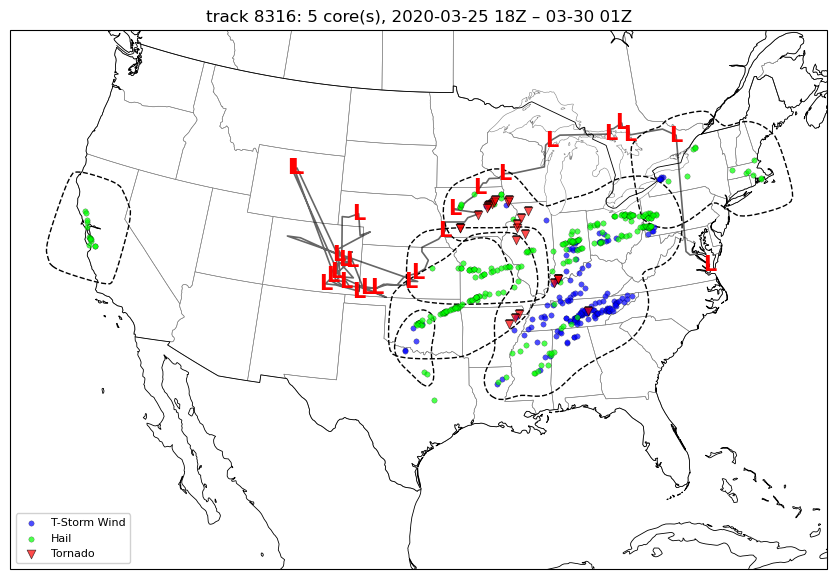

In [39]:
plot_track_cores(track_id=8316, df=df, tracks_h=tracks_h, savepath=False)

In [20]:
## Sensitivity test for window and gap_hours

def run_grid(df,
             windows=(9,12,15,18,24),
             gaps=(3,6,9,12),
             feb_track_id=None,
             bandwidth=1.0,
             pdf_thresh=0.001,
             min_reports=5):
    
    rows = []

    for win in windows:
        # one engine pass per window value
        core_local = pd.Series(-1, index=df.index, dtype=int)
        for tid, g in df.groupby('track_id'):
            core_local.loc[g.index] = kde_cluster_track(
                g, bandwidth=bandwidth, pdf_thresh=pdf_thresh,
                win_hours=win, min_reports=min_reports,
            )
        base = df.copy()
        base['core_local'] = core_local
        base['core_id'] = np.where(
            base['core_local'] >= 0,
            base['track_id'].astype(str) + '_' + base['core_local'].astype(str),
            np.nan,
        )

        ## apply each gap value to this window's cores
        for gap in gaps:
            cg = split_cores_on_gap(base, gap_hours=gap)
            assigned = cg.notna()

            n_cores = cg.dropna().nunique()
            n_assigned = int(assigned.sum())
            n_total = len(base)

            feb_cores = np.nan 
            if feb_track_id is not None:
                feb_mask = base['track_id'] == feb_track_id
                feb_cores = cg[feb_mask].dropna().nunique()

            rows.append({
                'win_hours': win,
                'gap_hours': gap,
                'n_cores_season': n_cores,
                'n_assigned': n_assigned,
                'assign_frac': round(n_assigned / n_total, 4),
                'feb_n_cores': feb_cores,
            })

    out = pd.DataFrame(rows).sort_values(['win_hours','gap_hours'])
    return out.reset_index(drop=True)

In [40]:
grid = run_grid(df, feb_track_id=8316)
print(grid.to_string(index=False))

 win_hours  gap_hours  n_cores_season  n_assigned  assign_frac  feb_n_cores
         9          3              36        2363       0.9752            5
         9          6              27        2363       0.9752            4
         9          9              26        2363       0.9752            4
         9         12              26        2363       0.9752            4
        12          3              38        2372       0.9790            5
        12          6              29        2372       0.9790            4
        12          9              27        2372       0.9790            4
        12         12              25        2372       0.9790            3
        15          3              39        2373       0.9794            6
        15          6              30        2373       0.9794            5
        15          9              28        2373       0.9794            5
        15         12              25        2373       0.9794            3
        18  

In [24]:
feb_track = df[df['track_id'] == 8308]

In [25]:
feb_track['core_id'].value_counts()

core_id
8308_1g1    98
8308_1g0     6
8308_0       5
Name: count, dtype: int64

In [41]:
def inspect_core_seams(track_id, df):
    """
    For one track, show each core's time span and the quiet gap BETWEEN
    consecutive cores. Long between-core gaps = defensible seams;
    very short ones = candidates for over-splitting.
    """
    g = df[df['track_id'] == track_id].dropna(subset=['core_id'])
    summary = (g.groupby('core_id')['time_hour']
                 .agg(['min', 'max', 'size'])
                 .sort_values('min'))
    summary['duration_h'] = (
        (summary['max'] - summary['min']).dt.total_seconds() / 3600
    )

    print(f"Track {track_id}: {len(summary)} cores\n")
    prev_end = None
    for cid, row in summary.iterrows():
        if prev_end is not None:
            seam = (row['min'] - prev_end).total_seconds() / 3600
            print(f"   --- quiet gap between cores: {seam:.1f} h ---")
        print(f"  {cid}: {row['min']:%m-%d %H}Z -> {row['max']:%m-%d %H}Z  "
              f"({row['duration_h']:.0f}h, {int(row['size'])} reports)")
        prev_end = row['max']

In [42]:
inspect_core_seams(8316, df)

Track 8316: 5 cores

  8316_0: 03-25 18Z -> 03-25 22Z  (4h, 13 reports)
   --- quiet gap between cores: 30.0 h ---
  8316_1g0: 03-27 04Z -> 03-27 07Z  (3h, 17 reports)
   --- quiet gap between cores: 10.0 h ---
  8316_1g1: 03-27 17Z -> 03-28 04Z  (11h, 65 reports)
   --- quiet gap between cores: 4.0 h ---
  8316_1g2: 03-28 08Z -> 03-29 10Z  (26h, 350 reports)
   --- quiet gap between cores: 7.0 h ---
  8316_2: 03-29 17Z -> 03-30 01Z  (8h, 18 reports)
